<a href="https://colab.research.google.com/github/VictorHugoTesti/-am-t4-s1a2026/blob/main/C%C3%B3pia_de_MultiNeuralCredit0602.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Random Forest | Digest Pickle [Fase 1 - credit_data]

## Importar dados Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas Python

In [ ]:
!pip -q install plotly
!pip -q install yellowbrick

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/Aprendizagem de Maquina/credit.pkt', 'rb') as f:
   X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, Y_credit_teste.shape

((1700, 3), (300,))

In [ ]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from warnings import warn
random_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None, criterion="entropy", max_depth='auto',
                        min_impurity_decrease=0.0, min_samples_split=None,
                        min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                        n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)


RandomForestClassifier(criterion='entropy', max_depth='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

## Criando Base Provisória

In [ ]:
previsoes_arvore = random_credit.predict(X_credit_teste)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(Y_credit_teste, previsoes_arvore)

0.9733333333333334

In [ ]:
confusion_matrix(Y_credit_teste, previsoes_arvore)

array([[257,   3],
       [  5,  35]])

In [ ]:
print(classification_report(Y_credit_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



In [ ]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

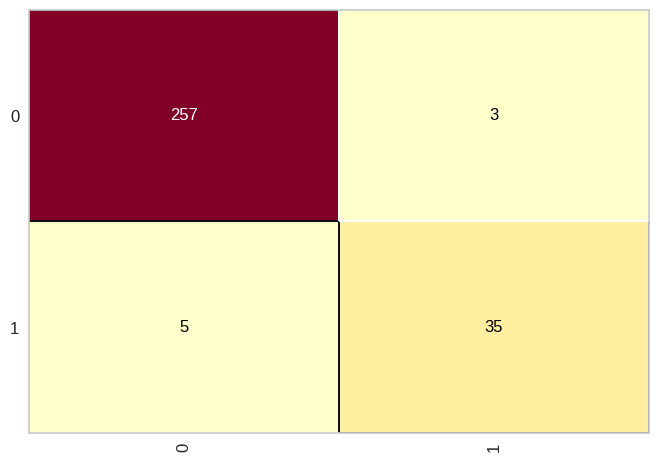

In [ ]:
cm_credit = ConfusionMatrix(random_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

# Pipeline Regressão | Digest [Fase 1 - credit_base]

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
regression_credit = LogisticRegression(random_state=1)
regression_credit.fit(X_credit_treinamento, Y_credit_treinamento)

In [ ]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_interceot=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100
                   multi_class='auto', n_jobs=None, penalty='12',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warn_start=False)

In [ ]:
regression_previsores = regression_credit.predict(X_credit_teste)
regression_previsores

In [ ]:
accuracy_score(Y_credit_teste, regression_previsores)

In [ ]:
from yellowbrick.classifier import ConfusionMatrix

In [ ]:
cm_credit = ConfusionMatrix(regression_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, regression_previsores))